# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name: DART (Diabetes Analytics & Research Team)
Created by Anh Tran (015621450), Willy Tang (SJSU ID), Jacob Atanacio (SJSU ID), Aziza  (SJSU ID)
Last updated: 3/26/2026

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

In [2]:
### Importing libraries
import numpy as np
import pandas as pd

# plotly libraries
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns

# matplotlib
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv('../diabetes_dataset.csv')
data.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [5]:
data.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


For our dataset, we checked for null count, formatting, and data types of each columns to ensure that we have clean and well organized dataset. From what we observed, there seems to be no null values and the data types are all the correct types.

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

#### Question:
Are there differences in measuring fasting glucose and prandial glucose for determining blood sugar levels, a factor considered for diabetes?

       diabetes_stage               measure  glucose
0              Type 2       glucose_fasting      136
1         No Diabetes       glucose_fasting       93
2              Type 2       glucose_fasting      118
3              Type 2       glucose_fasting      139
4              Type 2       glucose_fasting      137
...               ...                   ...      ...
199995   Pre-Diabetes  glucose_postprandial      109
199996   Pre-Diabetes  glucose_postprandial      146
199997    No Diabetes  glucose_postprandial      132
199998   Pre-Diabetes  glucose_postprandial      117
199999   Pre-Diabetes  glucose_postprandial      142

[200000 rows x 3 columns]


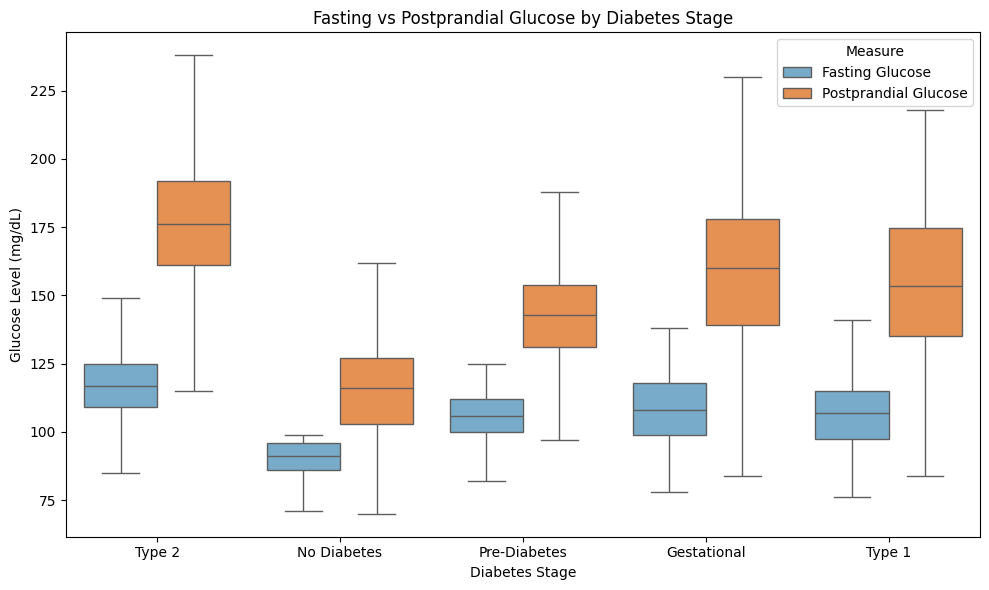

In [6]:


#Get just the columns for glucose levels during fasting and postprandial, as well as the diabetes_stages
glucose_df = data[["glucose_fasting", "glucose_postprandial", "diabetes_stage"]].dropna().copy()
#Conver thte glucose df into a long format so we can see the diabetees stage along with its measure of erither glucose fasting or glucose post prandial and their corresponding glucose level
long_df = glucose_df.melt(
    id_vars="diabetes_stage",
    value_vars=["glucose_fasting", "glucose_postprandial"],
    var_name="measure",
    value_name="glucose"
)
print(long_df)
#Replace the value so that it looks more clean rather than having the "_" so we can use this for the legend bvox
long_df["measure"] = long_df["measure"].replace({
    "glucose_fasting": "Fasting Glucose",
    "glucose_postprandial": "Postprandial Glucose"
})


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=long_df,
    x="diabetes_stage",
    y="glucose",
    hue="measure",
    palette=["#6baed6", "#fd8d3c"],
    showfliers=False
)

plt.title("Fasting vs Postprandial Glucose by Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Glucose Level (mg/dL)")
plt.legend(title="Measure")
plt.tight_layout()
plt.show()

#### Analysis:
Based on the categorical box plot, we can see teh different measurement in mg/dL of Fasting Glucose and Postprandial Glucose in the five types of diabetes stage. Furtheremore, when looking at an article from Mayo Clinic (https://www.mayoclinic.org/diseases-conditions/diabetes/diagnosis-treatment/drc-20371451), we are able to compare some of these values to ensure its accuracy. For instance, in our plot, people with no diabetes showed low level of Fasting Glucose level under 100 mg/dL, which corresponse with that was mentioned in the article, which stated that "A fasting blood sugar level less than 100 mg/dL (5.6 mmol/L) is normal". In addition, for people with pre-diabetes, a level between 100-125 mg/dL is displayed on the plot and Mayo Clinic mentioned that "A fasting blood sugar level from 100 to 125 mg/dL (5.6 to 6.9 mmol/L) is considered prediabetes." As you can see, the categorical box plot displays accurate analysis that corresponse with what is researched from Mayo Clinic.

### Q3: Come up with a another unique question. This question must use map() or apply()

How does a patient's fasting glucose level correlate with their HbA1c?

In [8]:
# Your code here . . .
def categorize_age(age):
    if age >= 65:
        return 'Senior'
    else:
        return 'Adult'

data['age_group'] = data['age'].apply(categorize_age)

correlation_by_age = data.groupby('age_group')[['glucose_fasting', 'hba1c']].corr().iloc[0::2, 1]

print(correlation_by_age)

age_group                 
Adult      glucose_fasting    0.695912
Senior     glucose_fasting    0.695385
Name: hba1c, dtype: float64


### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [ ]:
lifestyle = data.sample(1000)

lifestyle

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
76144,56,Male,Asian,Graduate,Upper-Middle,Retired,Never,1,212,6.3,...,53,128,241,120,124,11.94,6.06,27.7,Pre-Diabetes,0
44408,46,Male,White,Highschool,Low,Employed,Former,2,25,9.0,...,51,127,205,109,158,5.64,6.09,28.9,Pre-Diabetes,0
26155,90,Male,Black,Highschool,Upper-Middle,Retired,Never,1,80,3.8,...,48,61,137,123,151,11.83,6.53,40.5,Type 2,1
49097,30,Female,White,Highschool,Middle,Student,Never,4,64,7.3,...,58,89,192,117,131,2.00,5.97,38.7,Type 2,1
54757,40,Female,Hispanic,Highschool,High,Employed,Never,1,54,5.3,...,63,50,54,104,195,5.60,6.48,22.4,Pre-Diabetes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63127,19,Female,White,Graduate,Low,Retired,Never,2,119,2.5,...,39,130,192,96,167,16.25,6.25,22.8,Pre-Diabetes,0
94540,31,Female,Black,Highschool,Low,Employed,Never,3,185,10.0,...,57,73,147,110,127,2.03,5.40,17.5,Pre-Diabetes,0
4228,54,Male,Other,Highschool,Lower-Middle,Employed,Never,0,121,6.9,...,54,93,131,133,189,9.32,7.00,28.7,Type 2,1
13978,45,Male,Black,Postgraduate,Lower-Middle,Employed,Current,1,93,4.8,...,57,117,202,116,258,14.33,9.19,28.3,Type 2,1


In [ ]:
lifestyle = lifestyle[["physical_activity_minutes_per_week", "diet_score", "bmi", "diabetes_risk_score", "diagnosed_diabetes"]].sort_values(
    by="diabetes_risk_score", ignore_index=True)

lifestyle

,physical_activity_minutes_per_week,diet_score,bmi,diabetes_risk_score,diagnosed_diabetes
0,292,8.9,20.2,9.5,0
1,304,7.6,20.7,9.6,0
2,363,6.8,21.3,9.8,0
3,205,8.6,23.5,11.5,0
4,242,8.2,25.9,12.3,1
...,...,...,...,...,...
995,38,8.3,28.4,54.4,0
996,22,5.3,24.6,55.4,1
997,20,4.8,34.8,55.6,1
998,32,5.6,31.4,56.8,1


In [ ]:
color = list(np.random.choice(range(256), size=3))
print(color)

[np.int64(48), np.int64(131), np.int64(196)]


In [ ]:
lifestyle['activity_bin'] = (lifestyle['physical_activity_minutes_per_week'] // 50) * 50
lifestyle['bmi_bin']      = (lifestyle['bmi'] // 2) * 2
lifestyle['diet_bin']     = (lifestyle['diet_score'] // 1) * 1

df = lifestyle[
    (lifestyle['physical_activity_minutes_per_week'] <= 550) &
    (lifestyle['bmi'] <= 38)
].copy()

MIN_N = 30  

def make_pivot(df, row_col, col_col):
    agg = df.groupby([row_col, col_col])['diagnosed_diabetes'].agg(['mean','count']).reset_index()
    agg = agg[agg['count'] >= MIN_N]
    return agg.pivot(index=row_col, columns=col_col, values='mean')

p_act_bmi  = make_pivot(df, 'bmi_bin',  'activity_bin')   # BMI rows, Activity cols
p_act_diet = make_pivot(df, 'diet_bin', 'activity_bin')   # Diet rows, Activity cols
p_bmi_diet = make_pivot(df, 'diet_bin', 'bmi_bin')        # Diet rows, BMI cols

overall = df['diagnosed_diabetes'].mean()

colorscale = [
    [0.0,  '#1a4a8a'],
    [0.3,  '#378ADD'],
    [0.55, '#f5f0e8'],
    [0.75, '#D85A30'],
    [1.0,  '#7a1a00']
]

def heatmap_trace(pivot, xlab, ylab, name):
    x = [str(int(v) if v == int(v) else v) for v in pivot.columns]
    y = [str(int(v) if v == int(v) else v) for v in pivot.index]
    z = pivot.values.tolist()
    return go.Heatmap(
        x=x, y=y, z=z,
        colorscale=colorscale,
        zmin=0.3, zmax=0.85,
        colorbar=dict(
            title=dict(text='Diabetes rate', side='right'),
            tickformat='.0%',
            len=0.85
        ),
        hovertemplate=(
            xlab + ': %{x}<br>' +
            ylab + ': %{y}<br>' +
            'Diabetes rate: %{z:.1%}<extra>' + name + '</extra>'
        ),
        name=name,
        showscale=True
    )

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Activity × BMI',
        'Activity × Diet Score',
        'BMI × Diet Score'
    ),
    horizontal_spacing=0.10
)

fig.add_trace(heatmap_trace(p_act_bmi,  'Activity (min/wk)', 'BMI',        'Activity × BMI'),  row=1, col=1)
fig.add_trace(heatmap_trace(p_act_diet, 'Activity (min/wk)', 'Diet score', 'Activity × Diet'), row=1, col=2)
fig.add_trace(heatmap_trace(p_bmi_diet, 'BMI',               'Diet score', 'BMI × Diet'),       row=1, col=3)

fig.data[1].showscale = False
fig.data[2].showscale = False

fig.update_layout(
    title=dict(
        text='Combined Lifestyle Factor Influence on Diabetes Likelihood',
        font=dict(size=16)
    ),
    height=480,
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(t=80, b=60, l=60, r=80)
)

fig.update_xaxes(title_text='Activity (min/week)', row=1, col=1)
fig.update_yaxes(title_text='BMI',                 row=1, col=1)
fig.update_xaxes(title_text='Activity (min/week)', row=1, col=2)
fig.update_yaxes(title_text='Diet score',          row=1, col=2)
fig.update_xaxes(title_text='BMI',                 row=1, col=3)
fig.update_yaxes(title_text='Diet score',          row=1, col=3)

fig.show()

From this plot we can see that physical activity is the most actionable protective factor where individuals exercising 300+ minutes per week consistently show diabetes rates 15–20 percentage points lower than sedentary individuals, regardless of diet quality. BMI is the strongest single risk driver in the dataset, with diagnosis rates climbing steadily from 46% at healthy weights to over 74% at high BMI, and this elevated risk persists even among people with good diet scores. Diet score has the weakest independent influence of the three, suggesting that physical activity and weight management are far more critical levers for reducing diabetes likelihood than dietary choices alone.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

Additional datasets we need are the intersection of mental health and diabetes. Our dataset does not contain mental health data, which is what we are lacking. Additionally, our original data is synthetically created based on the statistical distribution of real data, and having another dataset with overlapping columns could help us to verify our results against world real data. Overall, another dataset will help us answer our fifth question on our project proposal:
"How does the combination of socioeconomic barriers and mental health influence the prevalence and management of diabetes?"

To combine our data, we will need to ensure our data is compatible: Certain columns may have differences in values if they should be the same type of feature. Additionally, we need to keep track of our data origins. Age will need to be tweaked to fit a range of values since BRFSS data utilizes it from a range like 18-24 as 1, 25 to 31 as 2, etc. But our dataset uses the actual age. We cannot exactly merge the data because it does not make sense to add to a patient's individual data with another person's individual data. Alternatively, we could also keep our data separate as a dataset to validate against. It may be better to use groupby instead to put similar data together. Another option is concatenate, but there may be a decent amount of columns that will be partially NaN. Our data concatenated will need further data cleaning to address NaN that didn't properly concatenate and make column names and values compatible with each other

 Reshaping with groupby rather than converting to long may be preferable as our columns are more like unique features rather than something such as each column representing a day. It would be difficult to combine columns into long form that aren't quite related enough and with varying scales and range of data. Groupby would help us to organize columns together and plot data and see certain details such as mean, proportion, count. Concatenating is also an option to combine synthetic and real world data

 BRFSS dataset: A survey of over 250k survey participants regarding diabetes stage, diagnosis, income, education, sex, age, mental health, general health, and more. It is real world data from the CDC. It has 21 columns and the data is not balanced and has been cleaned prior by user who posted the dataset
 https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data?select=diabetes_012_health_indicators_BRFSS2015.csv
 

In [ ]:
# Your code here . . .
# the complementary dataset BRFSS 2015
data2 = pd.read_csv('../diabetes_012_health_indicators_BRFSS2015.csv')
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [ ]:
data2.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Text(0.5, 1.0, 'Diabetes Distribution by Income Level')

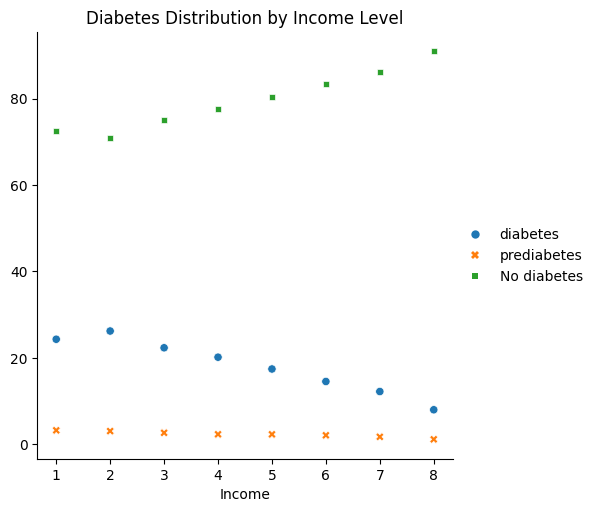

In [ ]:
# Need to group data for mental health and diabetes
# If I want to see income's relation to diabetes, i need the proportion of counted numbers to the total amount
# Represents the percentage of people at this income bracket with 0,1,2
# 
yes_diabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==2].count() / len(x) *100)
prediabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==1].count() / len(x) *100)
no_diabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==0].count() / len(x) *100)

diabetes_proportion = pd.DataFrame({"diabetes": yes_diabetes, 'prediabetes': prediabetes, 'No diabetes': no_diabetes})
# diabetes_proportion
# sns.catplot(data = data2, y ='Income', col = 'Diabetes_012', kind='count')
# diabetes_sample = data2.groupby('Income')['Diabetes_012']
# diabetes_sample
sns.relplot(diabetes_proportion)
plt.title("Diabetes Distribution by Income Level")


# sns.catplot(data = diabetes_sample, x = 'MentHlth', kind = 'count')

Text(0.5, 1.0, 'Diabetes Distribution by Mental Health Level')

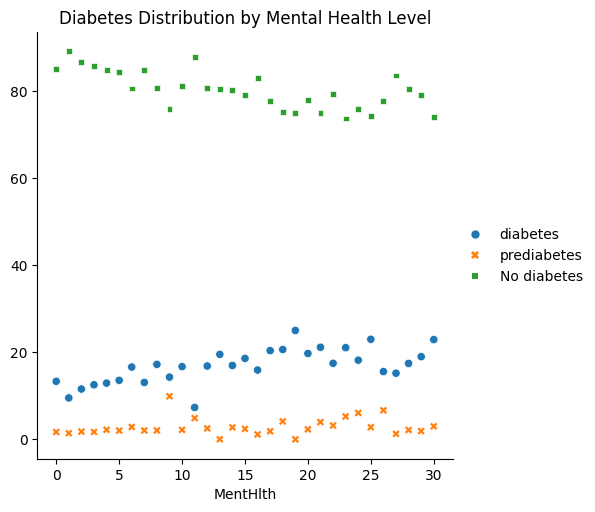

In [ ]:
# Find proportion of each mental health data and diabetes
mentalHealth3 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==2].count() / len(x) *100)
mentalHealth2 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==1].count() / len(x) *100)
mentalHealth1 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==0].count() / len(x) *100)

mentHlth_proportion = pd.DataFrame({"diabetes": mentalHealth3, 'prediabetes': mentalHealth2, 'No diabetes': mentalHealth1})
sns.relplot(mentHlth_proportion)
plt.title("Diabetes Distribution by Mental Health Level")

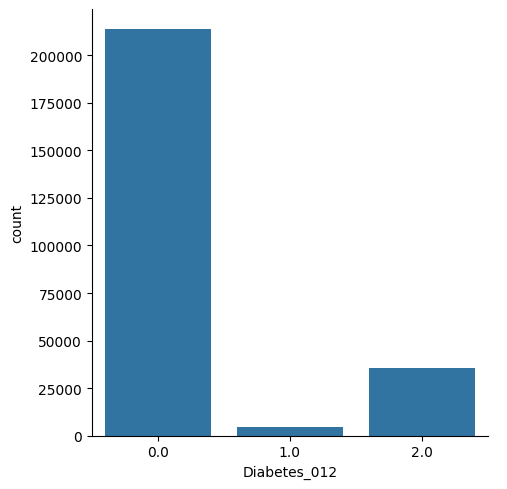

In [ ]:
sns.catplot(data2, x='Diabetes_012', kind='count')

Combining our dataset: Certain data needs to be on the same scale

In [ ]:
# function to convert to specific ages to age bucket
def combine_age(x):
    if (x > 80):
        return 13.0
    elif (79 >= x >= 75): 
        return 12.0
    elif (74 >= x >= 70):
        return 11.0
    elif (69 >= x >= 65):
        return 10.0
    elif (64 >= x >= 60):
        return 9.0
    elif (59 >= x >= 55):
        return 8.0
    elif (54 >= x >= 50):
        return 7.0
    elif (49 >= x >= 45):
        return 6.0
    elif (44 >= x >= 40):
        return 5.0
    elif (39 >= x >= 35):
        return 4.0
    elif (34 >= x >= 30):
        return 3.0
    elif (29 >= x >= 24):
        return 2.0
    elif (24 >= x >= 19):
        return 1.0

# changes string values of gender to digits
# with 2 being as 'Other'    
def gender_change(x):
    if x == 'Male':
        return 1.0
    elif x == 'Female':
        return 0.0
    else:
        return 2.0

In [ ]:
data['age'] = data['age'].apply(combine_age)
data['gender'] = data['gender'].apply(gender_change)
data['gender']

0        1.0
1        0.0
2        1.0
3        0.0
4        1.0
        ... 
99995    1.0
99996    0.0
99997    0.0
99998    0.0
99999    0.0
Name: gender, Length: 100000, dtype: float64

In [ ]:
# Some columns are renames for concatenating compatiblity. Education level will need a method to convert the numeric values to be equivalent to the string
# values
data2.rename(columns={'Age': 'age', 'Education':'education_level', 'Sex':'gender', 'BMI': 'bmi', 'Income':'income_level', 'Smoker': 'smoking_status', 'Diabetes_012': 'diabetes_stage'}, inplace=True)
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   diabetes_stage        253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   bmi                   253680 non-null  float64
 5   smoking_status        253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [ ]:
combined_data = pd.concat([data,data2])
combined_data.reset_index(inplace=True)
combined_data
# Concatenated data will need further modification to ensure compatibility

,index,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,...,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk
0,0,8.0,1.0,Asian,Highschool,Lower-Middle,Employed,Never,0.0,215.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,6.0,0.0,White,Highschool,Middle,Employed,Former,1.0,143.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,9.0,1.0,Hispanic,Highschool,Middle,Unemployed,Never,1.0,57.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,11.0,0.0,Black,Highschool,Low,Retired,Never,0.0,49.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,6.0,1.0,White,Graduate,Middle,Retired,Never,1.0,109.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353675,253675,5.0,1.0,NaN,6.0,7.0,NaN,0.0,NaN,NaN,...,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0
353676,253676,11.0,0.0,NaN,2.0,4.0,NaN,0.0,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0
353677,253677,2.0,0.0,NaN,5.0,2.0,NaN,0.0,NaN,NaN,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
353678,253678,7.0,1.0,NaN,5.0,1.0,NaN,0.0,NaN,NaN,...,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0


In [ ]:
combined_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 353680 entries, 0 to 353679
Data columns (total 47 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   index                               353680 non-null  int64  
 1   age                                 350791 non-null  float64
 2   gender                              353680 non-null  float64
 3   ethnicity                           100000 non-null  str    
 4   education_level                     353680 non-null  object 
 5   income_level                        353680 non-null  object 
 6   employment_status                   100000 non-null  str    
 7   smoking_status                      353680 non-null  object 
 8   alcohol_consumption_per_week        100000 non-null  float64
 9   physical_activity_minutes_per_week  100000 non-null  float64
 10  diet_score                          100000 non-null  float64
 11  sleep_hours_per_day                 1

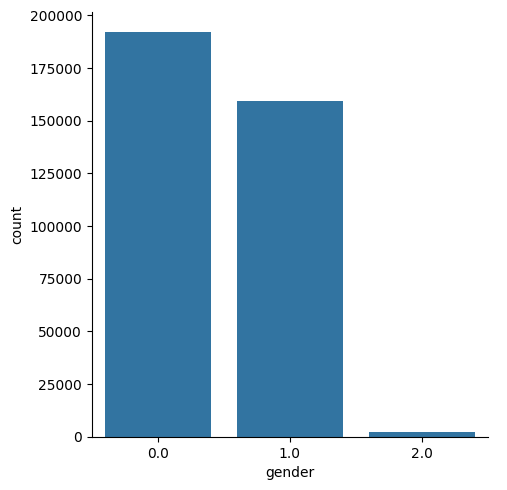

In [ ]:
sns.catplot(combined_data, x='gender', kind='count')

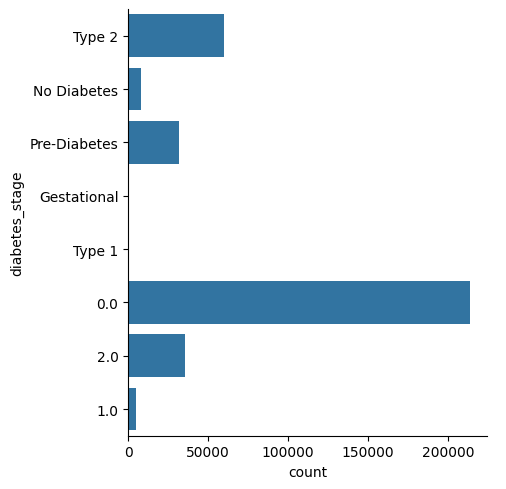

In [ ]:
sns.catplot(combined_data, y='diabetes_stage', kind='count')
# This data will need to later be adjusted to accomodate for changes to values to make it compatible

In [ ]:
# Making other columns consistent: Education and income
# function: rescale education
# education is like a bucket for each, find somehting in common
# for grades write conditions to convert brfss educaiton data
# if education is grade less than completed high school: no formal educaiton
# if educaiton is less than completed graduate: high school is highest
# if education is less than postgraduate: graduate is highest
# if completed postgraduate: postgraduate is highest

# a line of code to rename Education to education_level

# Then apply this function to BRFSS

# Income: Determine what scale is acceptable for 'low', 'medium', 'high' if possible
# Function to rescale income
# example: 1-3 is low, 4-6 is medium, 7-8 is high
# apply function to income

In [ ]:
# Reshaping data via groupby (not long or wide form)
# age_education = data.groupby(['age','education'])['diabetes_stage'].count()
# # show us the diabetes stage of how many people by age bucket and education

# lifestyle_habits = data.groupby(['alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score',
                                # 'sleep_hours_per_day', 'screen_time_hours_per_day'])['diabetes_stage']
# group lifestyle habits by current diabetes stage, could be later used to see extent it may correlate with diabetes risk  

# yes_diabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==2].count() / len(x) *100)
# prediabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==1].count() / len(x) *100)
# no_diabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==0].count() / len(x) *100) 
# From earlier, to show income and diabetes relation proportion, if any

# Find proportion of each mental health data and diabetes
# mentalHealth3 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==2].count() / len(x) *100)
# mentalHealth2 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==1].count() / len(x) *100)
# mentalHealth1 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==0].count() / len(x) *100)
# Also from earlier

# combined_data.groupby(['age','sex'])['diabetes_stage']
# diatetes stage will need to be modified to match the other dataset's column for diabetes level prior to concatenating